## Prepare data for annotation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import pickle
from tqdm import tqdm
from unidecode import unidecode
import re
import os
from dotenv import load_dotenv
import openai
from sklearn.metrics import classification_report


### Oon-narr relationship

First categorize it into broader categories:

In [4]:
relationships = {
    'parent': ['mom', 'mum', 'mother', 'dad', 'father', 'parent'],
    'sibling': ['brother', 'sister',  'sibling', 'cousin'],
    'partner': ['husband', 'wife', 'boyfriend', 'girlfriend', 'spouse', 'fiance', 'partner'],
    'extended_family': ['grandma', 'grandpa', 'grandfather', 'grandmother', 'grandparent', 'aunt', 'uncle'],
    'friend': ['friend', 'roommate', 'colleague'], # friend
}

#### Regex on title & selftext

In [5]:
df_post = pd.read_pickle('../data/oon/df_post_oon.pkl')

In [9]:
def check_rela(text):
    """
    Improved relationship extraction that handles possessives, in-laws, and self-references
    
    Returns:
        [detected: bool, relationship: str, flag: str]
        flag can be: 'clear', 'possessive', 'self_reference', 'multiple'
    """
    # Clean text
    processed_text = ''.join([char for char in text if char.isalnum() or char in " -'"])
    processed_text = unidecode(processed_text).lower()
        
    # Find all relationship mentions
    detected_relationships = []
    
    # Handle in-laws (add them to extended_family)
    inlaw_patterns = [
        r'\b(mother|mom|father|dad|brother|sister|son|daughter)\s*in\s*law\b',
        r'\b(mother|mom|father|dad|brother|sister|son|daughter)-in-law\b',
        r'\b(mother|mom|father|dad|brother|sister|son|daughter)\s*in-law\b',
    ]
    for pattern in inlaw_patterns:
        match = re.search(pattern, processed_text)
        if match:
            detected_relationships.append(match.group(0))
    
    # Check for self-reference patterns that indicate narrator is the OON
    self_reference_patterns = [
        r'\bmy \w+ helped me\b',  # "my husband helped me"
        r'\bi (left|exit|escaped|got out)\b',  # "I left QAnon"
        r'\bme (leaving|exiting|getting out)\b',  # "me leaving QAnon"
        r'\bhow i (left|exited|escaped|got out)\b',  # "how I left QAnon"
        r'\bmy journey (out|away)\b'  # "my journey out"
    ]
    
    for pattern in self_reference_patterns:
        if re.search(pattern, processed_text):
            return [False, '', 'self_reference']
    
    # Check for possessive patterns that indicate indirect relationship
    possessive_pattern = r"\b\w+\'s (mom|mother|dad|father|husband|wife|friend|brother|sister|daughter|son)\b" # "friend's mom"
    if re.search(possessive_pattern, processed_text):
        return [False, '', 'possessive']

    for category, words in relationships.items():
        for word in words:
            # Skip if the word is part of a previously matched phrase
            if any(word in detected_word for detected_word in detected_relationships):
                continue
 
            # Allow optional 'q' prefix (or other known prefixes)
            word_pattern = rf'(?:q)?{re.escape(word)}'
            
            direct_patterns = [
                rf'\bmy {word_pattern}\b',
                rf'\b{word_pattern} (is|was|has|had|been)\b',
                rf'\bthe {word_pattern}\b',
            ]
            
            is_direct = any(re.search(pattern, processed_text) for pattern in direct_patterns)
            
            if is_direct or word in processed_text.split():
                detected_relationships.append(word)
    
    # Remove duplicates while preserving order
    unique_relationships = []
    for rel in detected_relationships:
        if rel not in unique_relationships:
            unique_relationships.append(rel)
    
    # Handle results
    if len(unique_relationships) == 0:
        return [False, '', 'no_match']
    elif len(unique_relationships) == 1:
        return [True, unique_relationships[0], 'clear']
    else:
        # Multiple relationships detected - could be legitimate or noise
        # Return the first one but flag as multiple
        return [True, unique_relationships[0], 'multiple']

In [10]:
test_cases = [
    "Mom fell into QAnon conspiracy theories",  # parent
    "Wife's mother believes in deep state",        # possessive - should not detect
    "My step sister joined a cult",                # sibling
    "Mother in-law sharing conspiracy posts",      # in-law = extended
    "My husband helped me exit QAnon",             # self-reference
    "Friend's daughter got radicalized",           # possessive - should not detect
    "My boyfriend became alt-right",               # partner
    "I used to believe QAnon theories",            # self-reference, no relationship
    "Both my parents are conspiracy theorists",    # multiple same type
    "My son and husband are QAnon followers"       # multiple different types
]

print("=== TESTING RELATIONSHIP EXTRACTOR ===")
for i, test_text in enumerate(test_cases, 1):
    result = check_rela(test_text)
    print(f"{i:2d}. '{test_text}'")
    print(f"    Result: {result}")
    print()

=== TESTING RELATIONSHIP EXTRACTOR ===
 1. 'Mom fell into QAnon conspiracy theories'
    Result: [True, 'mom', 'clear']

 2. 'Wife's mother believes in deep state'
    Result: [False, '', 'possessive']

 3. 'My step sister joined a cult'
    Result: [True, 'sister', 'clear']

 4. 'Mother in-law sharing conspiracy posts'
    Result: [True, 'mother in-law', 'clear']

 5. 'My husband helped me exit QAnon'
    Result: [False, '', 'self_reference']

 6. 'Friend's daughter got radicalized'
    Result: [False, '', 'possessive']

 7. 'My boyfriend became alt-right'
    Result: [True, 'boyfriend', 'clear']

 8. 'I used to believe QAnon theories'
    Result: [False, '', 'no_match']

 9. 'Both my parents are conspiracy theorists'
    Result: [False, '', 'no_match']

10. 'My son and husband are QAnon followers'
    Result: [True, 'husband', 'clear']



In [ ]:
df_post_w_rela = df_post.copy(deep=True)

results = []

for idx, row in df_post_w_rela.iterrows():
    text = str(row['title']) if pd.notna(row['title']) else ""
    result = check_rela(text)
    results.append(result)

# Add results to DataFrame
df_post_w_rela['has_relationship'] = [r[0] for r in results]
df_post_w_rela['relationship_type'] = [r[1] for r in results]
df_post_w_rela['note'] = [r[2] for r in results]

Also selftext

In [ ]:
df_post_rest = df_post_w_rela[df_post_w_rela['note']!='clear']

In [ ]:
results2 = []

for idx, row in df_post_rest.iterrows():
    text = str(row['selftext'])
    result = check_rela(text)
    df_post_w_rela.at[idx, 'has_relationship'] = result[0]
    df_post_w_rela.at[idx, 'relationship_type'] = result[1]
    df_post_w_rela.at[idx, 'note'] = result[2]
    results2.append(result)

# Add results to DataFrame
df_post_rest['has_relationship'] = [r[0] for r in results2]
df_post_rest['relationship_type'] = [r[1] for r in results2]
df_post_rest['note'] = [r[2] for r in results2]

[The process includes manual check of real post titles for iterative qualitative evaluation, which was retrieved from the file for privacy/ethical consideration; Here we only keep self-written examples not coming from real texts]

#### LLM validation

In [ ]:
df_post_w_rela['relationship_cat'] = df_post_w_rela['relationship_type'].map(flat_mapping)
df_post_rest['relationship_cat'] = df_post_rest['relationship_type'].map(flat_mapping)

/dlabscratch1/bdoan/ipykernel_1931620/3160316833.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post_rest['relationship_cat'] = df_post_rest['relationship_type'].map(flat_mapping)


Now put the rest (ambiguous) into LLM

In [176]:
df_post_4_llm = df_post_rest[df_post_rest['note']!='clear']

In [179]:
rela_prompt = """
You are a helpful assistant analyzing Reddit posts from the subreddit r/QAnonCasualties. Your task is to identify the relationship between the narrator (the person writing the post) and the person they are describing (the object of narration, or OON), if such a relationship exists.

If the narrator is telling a personal story about someone they know who became radicalized by QAnon, output the precise relationship label (e.g., "mother", "father", "brother", "sister", "partner", "friend").
If the post is not about a specific person known to the narrator (e.g., general discussion, support, resource sharing, venting), return: "N/A".
If the post talks about a stranger or a person not clearly connected to the narrator, return: "stranger".
If multiple relationships are discussed, return the closest and most central one, prioritizing immediate family or partner.

Input:
Title: {{title}}
Body: {{selftext}}

Output:
Relationship: {{label}}


"""

In [ ]:
# Load environment variables from a .env file
load_dotenv()

# Get the API key
api_key = os.getenv("DLAB_API_KEY")
if not api_key:
    raise ValueError("DLAB_API_KEY not found in .env file or environment variables")

In [181]:
client = openai.OpenAI(api_key=api_key)

First validate with a sample of 500 self-reported relationships

In [ ]:
df_val_rela = df_post_w_rela[~df_post_w_rela.index.isin(df_post_4_llm.index)]

In [573]:
df_val_rela = df_val_rela.sample(500)[['selftext', 'title', 'relationship_type']]

In [574]:
for idx, row in tqdm(df_val_rela.iterrows(), total=len(df_val_rela)):
    result = check_relationship_llm(row)
    df_val_rela.at[idx, "predicted_relationship_type"] = result

100%|█████████████████████████████████████████| 500/500 [05:37<00:00,  1.48it/s]


In [576]:
# Remove quotation mark, excessive string
df_val_rela["predicted_relationship_type"] = df_val_rela["predicted_relationship_type"].apply(
    lambda x: x.split('Relationship: ')[-1].strip().strip('"').strip("'").lower()
)

In [586]:
# Helper function to clean and extract base term
def extract_base_relationship(rel):
    rel = rel.lower().strip()
    # Remove known prefixes and suffixes
    rel = re.sub(r'^(ex-|step|step-)', '', rel)
    rel = re.sub(r'-in-law$', '', rel)
    return rel

# Apply cleaning
df_val_rela.predicted_relationship_type = df_val_rela.predicted_relationship_type.apply(extract_base_relationship)

Map the specific relas to the higher categories

In [605]:
# Invert the mapping: leaf → category
flat_mapping = {leaf: cat for cat, leaves in relationships.items() for leaf in leaves}

# Map the relationship_type to its category
df_val_rela['relationship_cat'] = df_val_rela['relationship_type'].map(flat_mapping)
df_val_rela['predicted_relationship_cat'] = df_val_rela['predicted_relationship_type'].map(flat_mapping)

Validate

In [606]:
df_val_clean = df_val_rela.dropna(subset=['relationship_cat', 'predicted_relationship_cat'])

In [615]:
print(classification_report(df_val_clean['relationship_cat'], df_val_clean['predicted_relationship_cat'], labels=list(relationships.keys())))

                 precision    recall  f1-score   support

         parent       0.95      0.98      0.97       254
        sibling       0.93      0.97      0.95        38
        partner       0.93      0.90      0.92        78
extended_family       0.88      0.70      0.78        10
         friend       1.00      0.90      0.95        59

       accuracy                           0.95       439
      macro avg       0.94      0.89      0.91       439
   weighted avg       0.95      0.95      0.95       439



#### LLM Annotation

Now apply it to the whole thing

In [191]:
def check_relationship_llm(row):
    prompt = f"""
You are a helpful assistant analyzing Reddit posts from the subreddit r/QAnonCasualties. Your task is to identify the relationship of the person they are describing (the object of narration, or OON, who radicalized) to the narrator (the person writing the post), if such a relationship exists.

If the narrator is telling a personal story about someone they know who became radicalized by QAnon, output the precise relationship label (e.g., "mother", "father", "brother", "sister", "wife", "friend").
If the post is not about a specific person known to the narrator (e.g., general discussion, support, resource sharing), or if you are not sure, return: "N/A".
If the post talks about a stranger or a person not clearly connected to the narrator, return: "stranger".
If the post talks about the radicalization/recovery story of the narrator themselves, return: "self".
If multiple relationships are discussed, return the closest and most central one, prioritizing immediate family or partner.

Input:
Title: {row.title}
Body: {row.selftext}

Output:
Relationship:
"""
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini-2024-07-18",
            temperature=0.2,
            messages=[{"role": "user", "content": prompt}]
        )
        answer = response.choices[0].message.content.strip()
        return answer
    except Exception as e:
        return "ERROR"

In [192]:
for idx, row in tqdm(df_post_4_llm.iterrows(), total=len(df_post_4_llm)):
    result = check_relationship_llm(row)
    df_post_4_llm.at[idx, "relationship_type"] = result

100%|███████████████████████████████████████| 4712/4712 [44:39<00:00,  1.76it/s]


In [609]:
# Remove quotation mark, excessive string
df_post_4_llm["relationship_type"] = df_post_4_llm["relationship_type"].apply(
    lambda x: x.split('Relationship: ')[-1].strip().strip('"').strip("'").lower()
)

/dlabscratch1/bdoan/ipykernel_1931620/1085020393.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post_4_llm["relationship_type"] = df_post_4_llm["relationship_type"].apply(


In [641]:
df_post_4_llm["relationship_type"].value_counts()

relationship_type
mother                          1651
father                           584
n/a                              462
wife                             373
friend                           221
sister                           187
brother                          165
parents                          141
self                              94
mother-in-law                     67
aunt                              57
stranger                          56
daughter                          52
cousin                            46
son                               38
uncle                             34
partner                           31
grandmother                       29
father-in-law                     29
husband                           27
boyfriend                         26
sibling                           25
sister-in-law                     25
girlfriend                        23
brother-in-law                    19
parent                            15
ex-wife             

It's a bit messy so let's clean up the labels.

In [642]:
def normalize_relationship(rel):
    if not isinstance(rel, str):
        return None
    
    rel = rel.lower().strip()
    
    # Remove possessives
    rel = re.sub(r"'s\b", "", rel)
    
    # Standardize hyphens/spaces
    rel = rel.replace("-", " ").replace("_", " ")
    
    # Remove descriptors like step, half, ex, eldest, older, future, biological
    rel = re.sub(r"\b(step|second|half|ex|eldest|older|best|great|future|biological|stbxq|stbx)\b", "", rel)
    
    # Collapse multiple spaces
    rel = re.sub(r"\s+", " ", rel).strip()
    
    return rel

In [643]:
df_post_4_llm["relationship_type"] = df_post_4_llm["relationship_type"].apply(normalize_relationship)

In [ ]:
# Invert the mapping: leaf → category
flat_mapping = {leaf: cat for cat, leaves in relationships.items() for leaf in leaves}

# Map the relationship_type to its category
df_val_rela['relationship_cat'] = df_val_rela['relationship_type'].map(flat_mapping)
df_val_rela['predicted_relationship_cat'] = df_val_rela['predicted_relationship_type'].map(flat_mapping)

In [651]:
def classify_relationship(rel):
    # Anything with 'in law' goes to extended_family
    if "in law" in rel or "inlaw" in rel:
        return "extended_family"
    
    # Direct term match
    if rel in flat_mapping:
        return flat_mapping[rel]
    
    # Match by containing keyword
    for term, category in flat_mapping.items():
        if term in rel:
            return category
    
    return None

In [652]:
df_post_4_llm["relationship_cat"] = df_post_4_llm["relationship_type"].apply(classify_relationship)

In [653]:
df_post_4_llm.relationship_cat.value_counts(dropna=False)

relationship_cat
parent             2462
None                783
partner             534
sibling             438
extended_family     329
friend              228
Name: count, dtype: int64

[Again we did some qualitative check here (retrieved)]

Now we have to combine df_post_w_rela (regex with title) + df_post_rest (regex with selftext) + df_post_4_llm (llm annot)

In [ ]:
df_post_w_rela['relationship_cat'] = df_post_w_rela['relationship_type'].map(flat_mapping)
df_post_rest['relationship_cat'] = df_post_rest['relationship_type'].map(flat_mapping)

In [ ]:
# Start with your original full df
df_post_rela_all = df_post.copy()

# Fill results from each method
df_post_rela_all.loc[df_post_w_rela.index, 'relationship_type'] = df_post_w_rela['relationship_type']
df_post_rela_all.loc[df_post_w_rela.index, 'relationship_cat']   = df_post_w_rela['relationship_cat']
df_post_rela_all.loc[df_post_w_rela.index, 'rela_annot_source']  = 'regex-title'

df_post_rela_all.loc[df_post_rest.index, 'relationship_type'] = df_post_rest['relationship_type']
df_post_rela_all.loc[df_post_rest.index, 'relationship_cat']   = df_post_rest['relationship_cat']
df_post_rela_all.loc[df_post_rest.index, 'rela_annot_source']  = 'regex-selftext'

df_post_rela_all.loc[df_post_4_llm.index, 'relationship_type'] = df_post_4_llm['relationship_type']
df_post_rela_all.loc[df_post_4_llm.index, 'relationship_cat']   = df_post_4_llm['relationship_cat']
df_post_rela_all.loc[df_post_4_llm.index, 'rela_annot_source']  = 'llm'

In [694]:
df_post_rela_all.relationship_cat.value_counts(dropna=False)

relationship_cat
parent             5834
partner            1494
sibling            1083
friend             1060
None                783
extended_family     539
NaN                  67
Name: count, dtype: int64

So 850 out of 10860 (7.83%) posts has no detected relationships

### Demographics

Starting with simple regex (e.g I'm 32F, I (23M), I, 18F):

(doing something similar to [this](https://scholarworks.sjsu.edu/cgi/viewcontent.cgi?article=4643&context=faculty_rsca) - section 4.2.1)

#### Test 1 (matching age & gender altogether)

In [359]:
def extract_age_gender(text):
    if not isinstance(text, str):
        return None, None

    # Normalize text
    text = text.lower()
    
    # Common self-referential indicators
    self_referential = re.search(r"\b(i am|i’m|i'm|me|my|myself)\b", text)
    
    if not self_referential:
        return None, None  # no self-reference, likely not narrator's own age/gender
    
    # Patterns for age and gender, with optional brackets
    pattern = re.compile(
        r'[\(\[\s,]*'               # open brackets, space, or comma
        r'(?P<age>\d{2})'           # 2-digit age
        r'\s*'                      # optional space
        r'(?P<gender>[mf])'         # gender marker
        r'[\]\)\s,\.!?:;\-]*',      # optional closing, punctuation, etc.
        re.IGNORECASE
    )

    matches = pattern.findall(text)
    if not matches:
        return None, None

    # Return the first match that looks plausible
    for age, gender in matches:
        try:
            age = int(age)
            if 13 <= age <= 99 and gender.lower() in {'m', 'f'}:
                return age, gender.lower()
        except ValueError:
            continue

    return None, None

In [ ]:
df_test = df_post.copy(deep=True)[['selftext']]

In [361]:
# remove url
df_test['selftext'] = df_test['selftext'].apply(lambda x: re.sub(r'^https?:\/\/.*[\r\n]*', '', x, flags=re.MULTILINE))

In [362]:
# Apply function to DataFrame
df_test[['age', 'gender']] = df_test['selftext'].apply(
    lambda x: pd.Series(extract_age_gender(x))
)

#### Test 2 (also matched seperately)

combined with [this](https://aclanthology.org/2020.lrec-1.751.pdf)

In [541]:
def extract_age_gender_improved(text):
    if not isinstance(text, str):
        return None, None
    
    # Normalize text
    text = text.lower()
    
    # More comprehensive self-referential check
    self_referential = re.search(
        r"\b(i am|i'm|i'm|me|my|myself|i was|i will be|i have|i've)\b", 
        text
    )
    
    if not self_referential:
        return None, None
    
    age = extract_age(text)
    gender = extract_gender(text)
    
    return age, gender

def extract_age(text):
    # Pattern 0: Original compact format (25m, 30f, etc.)
    compact_pattern = re.compile(
        r'\b(?:I\s*am|I\'m|I)\s*'       # match 'I', 'I'm', or 'I am' with optional spacing
        r'[\(\[\s,]*'                   # optional open bracket, space, or comma
        r'(?P<age>\d{2})'               # 2-digit age
        r'\s*'                          # optional space
        r'(?P<gender>[mf])'            # gender marker
        r'[\]\)\s,\.!?:;\-]*',         # optional closing, punctuation, etc.
        re.IGNORECASE
    )
    match = compact_pattern.search(text)
    if match:
        try:
            age = int(match.group('age'))
            if 13 <= age <= 99:
                return age
        except ValueError:
            pass

    # Pattern 1: "I'm/I am a X-year-old"
    year_old_hyphen_pattern = re.compile(r'\b(?:i\'?m|i\s+am)\s+(?:a\s+)?(\d{2})-year-old\b', re.IGNORECASE)
    match = year_old_hyphen_pattern.search(text)
    if match:
        try:
            age = int(match.group(1))
            if 13 <= age <= 99:
                return age
        except ValueError:
            pass
    
    # Pattern 2: "I am/I'm X years old"
    years_old_pattern = re.compile(r'\b(?:i\'?m|i\s+am)\s+(\d{2})\s+years?\s+old\b', re.IGNORECASE)
    match = years_old_pattern.search(text)
    if match:
        try:
            age = int(match.group(1))
            if 13 <= age <= 99:
                return age
        except ValueError:
            pass
    
    # Pattern 3: "I am/I'm a X year old"
    year_old_pattern = re.compile(r'\b(?:i\'?m|i\s+am)\s+a?\s*(\d{2})\s+years?\s+old\b', re.IGNORECASE)
    match = year_old_pattern.search(text)
    if match:
        try:
            age = int(match.group(1))
            if 13 <= age <= 99:
                return age
        except ValueError:
            pass
    
    # Pattern 4: "I'm/I am X" followed by punctuation - but exclude obvious non-ages
    age_punct_pattern = re.compile(
        r'\b(?:i\'?m|i\s+am)\s+(\d{2})(?=\s*[.,!?;:]|\s+(?:and|but|or|so|yet|for|nor|btw)\b|\s*$)',
        re.IGNORECASE
    )
    match = age_punct_pattern.search(text)
    if match:
        try:
            age = int(match.group(1))
            if 13 <= age <= 99:
                # Additional check: make sure it's not followed by obvious non-age indicators
                match_end = match.end()
                following_text = text[match_end:match_end+20].lower()
                
                # Skip if followed by units that indicate it's not an age
                if re.match(r'\s*(minutes?|mins?|hours?|hrs?|miles?|million|thousand|%|percent)', following_text):
                    return None

                # Check if the match is part of a decimal or percentage
                decimal_check = re.match(r'\s*\.\d|\s*%', text[match.end():match.end() + 5])
                if decimal_check:
                    return None
                    
                return age
        except ValueError:
            pass
            
    return None

def extract_gender(text):
    # Pattern 0: Original compact format (25m, 30f, etc.)
    compact_pattern = re.compile(
        r'\b(?:I\s*am|I\'m|I)\s*'       # match 'I', 'I'm', or 'I am' with optional spacing
        r'[\(\[\s,]*'                   # optional open bracket, space, or comma
        r'(?P<age>\d{2})'               # 2-digit age
        r'\s*'                          # optional space
        r'(?P<gender>[mf])'            # gender marker
        r'[\]\)\s,\.!?:;\-]*',         # optional closing, punctuation, etc.
        re.IGNORECASE
    )
    match = compact_pattern.search(text)
    if match:
        return match.group('gender').lower()
            
    # Female indicators
    female_patterns = [
        r'\bi\s+am\s+a?\s*(woman|female|girl|lady|wife|mother|sister)\b',
        r'\bi\'?m\s+a?\s*(woman|female|girl|lady|wife|mother|sister)\b',
        # Direct statements without articles
        r'\bi\'?m\s+(female)\b',
        r'\bi\s+am\s+(female)\b',
        # Handle patterns like "I'm a 25-year-old woman" (self-referential)
        r'\bi\'?m\s+a?\s*\d{2}-year-old\s+(woman|female|girl|lady)\b',
        r'\bi\s+am\s+a?\s*\d{2}-year-old\s+(woman|female|girl|lady)\b',
        # Handle "and female" in context
        r'\band\s+(female)\b',
        # More restrictive flexible match
        r'\bi\s+am\s+\w{1,10}\s+(female)\b',  # "I am currently female", etc.
    ]
    
    # Male indicators
    male_patterns = [
        r'\bi\s+am\s+a?\s*(man|male|boy|gentleman|guy|husband|father|brother)\b',
        r'\bi\'?m\s+a?\s*(man|male|boy|gentleman|guy|husband|father|brother)\b',
        # Direct statements without articles
        r'\bi\'?m\s+(male)\b',
        r'\bi\s+am\s+(male)\b',
        # Handle patterns like "I'm a 25-year-old man" (self-referential)
        r'\bi\'?m\s+a?\s*\d{2}-year-old\s+(man|male|boy|guy)\b',
        r'\bi\s+am\s+a?\s*\d{2}-year-old\s+(man|male|boy|guy)\b',
        # Handle "and male" in context
        r'\band\s+(male)\b',
        # More restrictive flexible match
        r'\bi\s+am\s+\w{1,10}\s+(male)\b',  # "I am currently male", etc.
        # Handle "I'm a guy"
        r'\bi\'?m\s+a\s+(guy)\b',
    ]
    
    
    # Check for female indicators
    for pattern in female_patterns:
        if re.search(pattern, text, re.IGNORECASE):
            return 'f'
    
    # Check for male indicators
    for pattern in male_patterns:
        if re.search(pattern, text, re.IGNORECASE):
            return 'm'
    
    return None

In [475]:
test_cases = [
    "Hi, I'm a 25-year-old woman looking for advice",
    "I am 30 years old and male",
    "I'm (25m) and need help",
    "I am a 22 year old female student",
    "I'm 28 and I'm married",
    "I'm a mother of two, 35 years old",
    "As a 40-year-old father, I...",
    "I'm 19 but feel older",
]

for text in test_cases:
    age, gender = extract_age_gender_improved(text)
    print(f"Text: {text}")
    print(f"Age: {age}, Gender: {gender}")
    print("-" * 50)

Text: Hi, I'm a 25-year-old woman looking for advice
Age: 25, Gender: f
--------------------------------------------------
Text: I am 30 years old and male
Age: 30, Gender: m
--------------------------------------------------
Text: I'm (25m) and need help
Age: 25, Gender: m
--------------------------------------------------
Text: I am a 22 year old female student
Age: 22, Gender: f
--------------------------------------------------
Text: I'm 28 and I'm married
Age: 28, Gender: None
--------------------------------------------------
Text: I'm a mother of two, 35 years old
Age: None, Gender: f
--------------------------------------------------
Text: As a 40-year-old father, I...
Age: None, Gender: None
--------------------------------------------------
Text: I'm 19 but feel older
Age: 19, Gender: None
--------------------------------------------------


In [ ]:
df_test2 = df_post.copy(deep=True)[['selftext']]

In [455]:
# remove url
df_test2['selftext'] = df_test2['selftext'].apply(lambda x: re.sub(r'https?://\S+', '', x))

In [544]:
# Apply function to DataFrame
df_test2[['age', 'gender']] = df_test2['selftext'].apply(
    lambda x: pd.Series(extract_age_gender_improved(x))
)

Text(0.5, 0, 'Age')

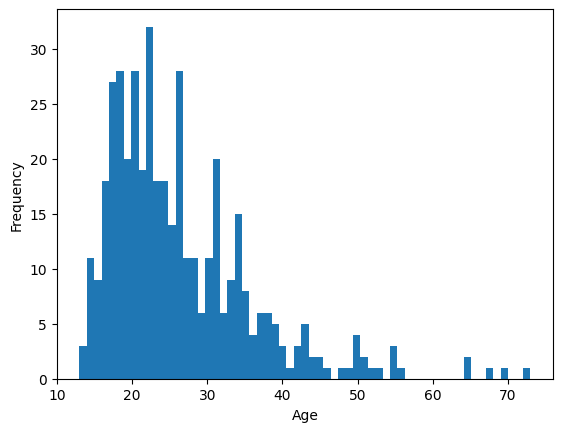

In [736]:
ax = df_test2['age'][df_test2['age'].notna()].plot.hist(bins=61)
ax.set_xlabel('Age')

We will define 2 age groups: adolescence (13-20) and adult (21+)

In [493]:
def map_age_group(age):
    if pd.isnull(age):
        return None
    return 'adolescence' if age <= 20 else 'adult'

df_test2['age_group'] = df_test2['age'].apply(map_age_group)

In [547]:
df_test2['gender'][df_test2['gender'].notna()].value_counts()

gender
f    162
m     72
Name: count, dtype: int64

In [ ]:
# Find rows where 'age' is None (or NaN) in df_test but not in df_test2
mask = df_test['age'].isna() & df_test2['age'].notna()

# Apply the mask to get the relevant rows from either DataFrame
result = df_test[mask]

#### Testing with LLM

##### Age

1. Masking the detected pattern in the text

In [696]:
def mask_age_gender(text):
    if not isinstance(text, str):
        return text
    
    # Mask compact patterns like "25M" or "30F"
    text = re.sub(r'\b(\d{2})\s*([mf])\b', '', text, flags=re.IGNORECASE)
    
    # Mask "I'm 25", "I am 25 years old", etc.
    text = re.sub(r"\b(i\s*'?am|i'm)\s*(a\s*)?(\d{2})(\s*-?\s*year[-\s]?old)?\b", r"\1", text, flags=re.IGNORECASE)
    
    # Mask gender terms (girl, guy, woman, man, etc.)
    # gender_terms = r'\b(girl|guy|woman|man|female|male|boy|lady|wife|husband|mother|father|brother|sister)\b'
    # Mask _direct_ gender terms
    gender_terms = r'\b(female|male)\b'
    text = re.sub(gender_terms, '', text, flags=re.IGNORECASE)
    
    return text

df_test2['masked_selftext'] = df_test2['selftext'].apply(mask_age_gender)

2. Run LLM (gpt-4o-mini) to detect gender and age

In [500]:
df_test2_age = df_test2[df_test2['age'].notna()]

In [509]:
def predict_age(text):
    prompt = f"""
You are a helpful assistant analyzing Reddit posts from the subreddit r/QAnonCasualties. Your task is to estimate the narrator's age group, which is either "adolescence" (13-20) or "adult" (21+).
If unsure, return: "N/A".

Input: "{text}"

Output:"""
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini-2024-07-18",
            temperature=0.2,
            messages=[{"role": "user", "content": prompt}]
        )
        answer = response.choices[0].message.content.strip()
        return answer
    except Exception as e:
        return "ERROR"

[Some qualitative check here]

In [513]:
for idx, row in tqdm(df_test2_age.iterrows(), total=len(df_test2_age)):
    result = predict_age(row['masked_selftext'])
    df_test2_age.at[idx, "predicted_age_group"] = result

100%|█████████████████████████████████████████| 427/427 [05:17<00:00,  1.34it/s]


In [517]:
df_test2_age.predicted_age_group = df_test2_age.predicted_age_group.apply(lambda x: x.lower())

/dlabscratch1/bdoan/ipykernel_1931620/3670318620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test2_age.predicted_age_group = df_test2_age.predicted_age_group.apply(lambda x: x.lower())


In [518]:
df_test2_age.predicted_age_group.value_counts(dropna=False)

predicted_age_group
adult          217
adolescence    150
n/a             60
Name: count, dtype: int64

##### Gender

In [697]:
df_test2_gender = df_test2[df_test2['gender'].notna()]

In [549]:
def predict_gender(text):
    prompt = f"""
You are a helpful assistant analyzing Reddit posts from the subreddit r/QAnonCasualties. Your task is to estimate the narrator's gender, which is either "f" (female) or "m" (male).
If unsure, return: "N/A".

Input: "{text}"

Output:"""
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini-2024-07-18",
            temperature=0.2,
            messages=[{"role": "user", "content": prompt}]
        )
        answer = response.choices[0].message.content.strip()
        return answer
    except Exception as e:
        return "ERROR"

In [698]:
for idx, row in tqdm(df_test2_gender.iterrows(), total=len(df_test2_gender)):
    result = predict_gender(row['masked_selftext'])
    df_test2_gender.at[idx, "predicted_gender"] = result

  0%|                                                   | 0/234 [00:00<?, ?it/s]/dlabscratch1/bdoan/ipykernel_1931620/810847625.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test2_gender.at[idx, "predicted_gender"] = result
100%|█████████████████████████████████████████| 234/234 [03:24<00:00,  1.14it/s]


In [699]:
df_test2_gender.predicted_gender.value_counts(dropna=False)

predicted_gender
f      168
N/A     34
m       32
Name: count, dtype: int64

3. Measure accuracy / F1 score

In [520]:
print(classification_report(df_test2_age['age_group'], df_test2_age['predicted_age_group'], labels=['adolescence', 'adult']))

              precision    recall  f1-score   support

 adolescence       0.75      0.78      0.76       144
       adult       0.89      0.68      0.77       283

   micro avg       0.83      0.71      0.77       427
   macro avg       0.82      0.73      0.77       427
weighted avg       0.84      0.71      0.77       427



In [700]:
print(classification_report(df_test2_gender['gender'], df_test2_gender['predicted_gender'], labels=['f', 'm']))

              precision    recall  f1-score   support

           f       0.83      0.86      0.84       162
           m       0.94      0.42      0.58        72

   micro avg       0.84      0.72      0.78       234
   macro avg       0.88      0.64      0.71       234
weighted avg       0.86      0.72      0.76       234



#### LLM Annotation

In [ ]:
# Apply gender & age extraction function to DataFrame
df_post[['age', 'gender']] = df_post['selftext'].apply(
    lambda x: pd.Series(extract_age_gender_improved(x))
)

In [ ]:
df_post['age_group'] = df_post['age'].apply(map_age_group)

In [ ]:
for idx, row in tqdm(df_post.iterrows(), total=len(df_post)):
    if pd.isna(row['age']): df_post.at[idx, "age_group"] = predict_age(row['selftext'])
    if pd.isna(row['gender']): df_post.at[idx, "gender"] = predict_gender(row['selftext'])

 13%|████▊                               | 1445/10860 [19:13<1:49:49,  1.43it/s]

In [ ]:
df_post.age_group.value_counts(dropna=False)

age_group
adult                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                3878
N/A                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [ ]:
def normalize_age_group(value):
    if pd.isna(value):
        return 'N/A'
    val = str(value).strip().lower()
    
    # Handle text that contains the keywords
    if 'adult' in val:
        return 'adult'
    if 'adolescence' in val:
        return 'adolescence'
    
    return 'N/A'

df_post['age_group'] = df_post['age_group'].apply(normalize_age_group)

In [ ]:
df_post.age_group.value_counts()

age_group
adult          5449
N/A            3436
adolescence    1975
Name: count, dtype: int64

In [ ]:
df_post.gender.value_counts()

gender
f      6359
N/A    3264
m      1237
Name: count, dtype: int64

In [734]:
df_post_rela_all['relationship_cat'].value_counts()

relationship_cat
parent             5834
partner            1494
sibling            1083
friend             1060
N/A                 850
extended_family     539
Name: count, dtype: int64

In [732]:
df_post_rela_all['relationship_cat'] = df_post_rela_all['relationship_cat'].apply(lambda x: "N/A" if pd.isna(x) else x)

In [ ]:
df_post['relationship_cat'] = df_post_rela_all['relationship_cat']
df_post.to_pickle('./data/oon/df_post_full.pkl')